# Laboratorio 6 - Task 1

<style>
.highlight pre, .output_area pre { white-space: pre-wrap !important; word-break: break-word; }
</style>


## 1. Q-Learning tabular y DQN

LunarLanderContinuous-v2 usa dos acciones continuas: la fuerza de cada propulsor. Esto significa que hay infinitas acciones posibles. Q-Learning tabular no sirve porque tendría que guardar un valor $Q(s,a)$ para cada estado y cada acción posible.

Tanto Q-Learning como DQN necesitan calcular $\arg\max_a Q(s,a)$ para elegir la mejor acción. Esto es fácil cuando hay pocas acciones discretas, pero no cuando $a$ es un vector continuo. DQN representa una política indirecta: primero calcula valores Q y luego elige el mayor. Para este caso es más natural representar directamente una política continua que genere acciones.

## 2. Gradiente de la política Gaussiana

La política es una Gaussiana acotada cuya media $\mu_\theta(s)$ sale de una red neuronal y cuya escala se aprende. Para una acción $a=\tanh(z)$, con $z\sim\mathcal{N}(\mu_\theta(s),\sigma_\theta)$, la log-probabilidad incluye el Jacobiano de la transformación:

$$\log\pi_\theta(a\mid s)=\log\mathcal{N}(\operatorname{atanh}(a);\mu_\theta(s),\sigma_\theta)-\sum_i\log(1-a_i^2+\varepsilon).$$

La escala es un parámetro aprendible independiente del estado, inicializado en $\sigma=0.5$. La corrección $-\log(1-a^2)$ evita tratar como Gaussiana una acción que ya fue transformada a $[-1,1]$.

Para el Actor se usa $-\log\pi_\theta(a_t\mid s_t)\hat A_t$; PyTorch obtiene automáticamente el gradiente de la media y de $\log\sigma$.

En simple: se compara la acción tomada con la media que propuso la red y se ajustan los pesos de la red en esa dirección, manteniendo siempre acciones válidas.

## 3. REINFORCE con línea base vs. Actor-Critic

REINFORCE con línea base usa $\hat A_t=G_t-b(S_t)$: el retorno completo menos una estimación del valor del estado. Si la línea base solo depende del estado, no agrega sesgo. Sin embargo, el retorno completo tiene mucha varianza porque depende de todo lo que ocurre hasta terminar el episodio.

Actor-Critic suele usar $\hat A_t=R_{t+1}+\gamma V_w(S_{t+1})-V_w(S_t)$. Tiene menos varianza porque aprende con información inmediata, pero puede tener sesgo si el Critic estima mal el valor de los estados.

Esperamos que Actor-Critic converja más rápido. En LunarLander hay muchas decisiones por episodio y el Critic da una señal de aprendizaje más frecuente. REINFORCE es más simple, pero suele aprender de forma más inestable.

## 4. Suavidad de acciones en el exoesqueleto

Se puede castigar en la recompensa que la acción cambie demasiado entre un instante y otro:

$$r'_t=r_t-\lambda\lVert a_t-a_{t-1}\rVert^2.$$

También conviene limitar la fuerza máxima y la rapidez con que puede cambiar. La política puede recibir la acción anterior y generar solo un cambio pequeño: $a_t=a_{t-1}+\Delta a_t$.

La elección no cambia: Actor-Critic sigue siendo una mejor opción inicial porque normalmente necesita menos datos. Aun así, en un sistema real se deben usar límites de seguridad además de la recompensa.

## 5. Implementación desde cero: REINFORCE y Actor-Critic

La siguiente implementación usa PyTorch únicamente para definir las redes y calcular gradientes automáticamente. La política es una Gaussiana continua transformada: su media sale de una red MLP con dos capas ocultas de 64 neuronas y ReLU, seguida de `tanh`; `log_std` es un parámetro aprendible independiente del estado, inicializado para que `sigma = 0.5`. La transformación `tanh` y su corrección de Jacobiano mantienen consistente la probabilidad con las acciones que recibe el entorno.

In [1]:
import math
from io import BytesIO
import random

import matplotlib.pyplot as plt
from IPython.display import Image, display
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

try:
    import gymnasium as gym
except ImportError:
    import gym

SEED = 42
N_EPISODES = 1000
GAMMA = 0.99
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ENV_CANDIDATES = ('LunarLanderContinuous-v2', 'LunarLanderContinuous-v3')


def set_seed(seed):
    """Fija todas las fuentes de aleatoriedad usadas por el experimento."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_env(render_mode=None):
    """Crea el entorno y admite Gymnasium moderno y Gym legacy."""
    last_error = None
    for env_id in ENV_CANDIDATES:
        attempts = ([{'render_mode': render_mode}, {}] if render_mode is not None else [{}])
        for kwargs in attempts:
            try:
                return gym.make(env_id, **kwargs)
            except Exception as error:
                last_error = error
    raise RuntimeError(
        'No se pudo crear LunarLanderContinuous. Instala gymnasium[box2d].'
    ) from last_error


def reset_env(env, seed=None):
    """Normaliza reset() para Gymnasium y versiones antiguas de Gym."""
    try:
        result = env.reset(seed=seed) if seed is not None else env.reset()
    except TypeError:
        if seed is not None and hasattr(env, 'seed'):
            env.seed(seed)
        result = env.reset()
    return result[0] if isinstance(result, tuple) else result


def step_env(env, action):
    """Normaliza step() a (estado, recompensa, terminado, truncado, info)."""
    result = env.step(action)
    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
    else:
        next_state, reward, done, info = result
        terminated, truncated = bool(done), False
    return next_state, float(reward), bool(terminated), bool(truncated), info


def render_frame(env, mode='rgb_array'):
    """Normaliza render() moderno y render(mode=...) de Gym legacy."""
    try:
        return env.render(mode=mode)
    except (TypeError, ValueError):
        return env.render()


def state_tensor(state):
    tensor = torch.as_tensor(np.asarray(state), dtype=torch.float32, device=DEVICE)
    return tensor.unsqueeze(0) if tensor.ndim == 1 else tensor


def clamp_log_std(module):
    """Evita escalas numéricamente inestables sin dejar de aprender sigma."""
    with torch.no_grad():
        module.log_std.clamp_(math.log(0.05), math.log(2.0))


def gradient_norm_from_tensors(gradients):
    valid_gradients = [gradient.detach() for gradient in gradients if gradient is not None]
    if not valid_gradients:
        return 0.0
    squared_norm = torch.stack([gradient.pow(2).sum() for gradient in valid_gradients]).sum()
    return float(torch.sqrt(squared_norm).cpu())


def display_figure(figure):
    """Embebe una figura PNG para que el notebook conserve la visualizacion."""
    buffer = BytesIO()
    figure.savefig(buffer, format='png', dpi=120, bbox_inches='tight')
    display(Image(data=buffer.getvalue(), format='png'))
    plt.close(figure)


### 5.1 Redes de política, línea base y Actor-Critic

`GaussianPolicy` y `ValueNetwork` son redes separadas para REINFORCE. En `ActorCritic`, `shared` se usa tanto para la cabeza de la media como para la cabeza escalar del valor; por eso el Critic comparte el cuerpo con el Actor.

In [2]:
class GaussianPolicy(nn.Module):
    """Politica Gaussiana continua para REINFORCE."""

    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(64, action_dim)
        self.log_std = nn.Parameter(
            torch.full((action_dim,), math.log(0.5), dtype=torch.float32)
        )

    def forward(self, states):
        if states.ndim == 1:
            states = states.unsqueeze(0)
        mean = torch.tanh(self.mean_head(self.shared(states)))
        std = self.log_std.exp().expand_as(mean)
        return mean, std

    def distribution(self, states):
        mean, std = self(states)
        return Normal(mean, std)

    @staticmethod
    def squashed_log_prob(distribution, pre_tanh_action, action):
        log_prob = distribution.log_prob(pre_tanh_action)
        correction = torch.log(1.0 - action.pow(2) + 1e-6)
        return (log_prob - correction).sum(dim=-1)

    def sample(self, states):
        distribution = self.distribution(states)
        pre_tanh_action = distribution.rsample()
        action = torch.tanh(pre_tanh_action)
        log_prob = self.squashed_log_prob(distribution, pre_tanh_action, action)
        entropy = -log_prob.detach()
        return action, log_prob, entropy

    def evaluate(self, states, actions):
        distribution = self.distribution(states)
        action = actions.clamp(-1.0 + 1e-6, 1.0 - 1e-6)
        pre_tanh_action = torch.atanh(action)
        log_prob = self.squashed_log_prob(distribution, pre_tanh_action, action)
        entropy = -log_prob.detach()
        return log_prob, entropy

    def mean_action(self, states):
        return self(states)[0]


class ValueNetwork(nn.Module):
    """Linea base V_pi(s) independiente de la politica."""

    def __init__(self, state_dim):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        self.value_head = nn.Linear(64, 1)

    def forward(self, states):
        if states.ndim == 1:
            states = states.unsqueeze(0)
        return self.value_head(self.body(states))


class ActorCritic(nn.Module):
    """Actor y Critic con un cuerpo MLP compartido."""

    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(64, action_dim)
        self.value_head = nn.Linear(64, 1)
        self.log_std = nn.Parameter(
            torch.full((action_dim,), math.log(0.5), dtype=torch.float32)
        )

    def forward(self, states):
        if states.ndim == 1:
            states = states.unsqueeze(0)
        features = self.shared(states)
        mean = torch.tanh(self.mean_head(features))
        std = self.log_std.exp().expand_as(mean)
        value = self.value_head(features)
        return mean, std, value

    def distribution(self, states):
        mean, std, _ = self(states)
        return Normal(mean, std)

    @staticmethod
    def squashed_log_prob(distribution, pre_tanh_action, action):
        log_prob = distribution.log_prob(pre_tanh_action)
        correction = torch.log(1.0 - action.pow(2) + 1e-6)
        return (log_prob - correction).sum(dim=-1)

    def sample(self, states):
        distribution = self.distribution(states)
        pre_tanh_action = distribution.rsample()
        action = torch.tanh(pre_tanh_action)
        log_prob = self.squashed_log_prob(distribution, pre_tanh_action, action)
        entropy = -log_prob.detach()
        return action, log_prob, entropy

    def value(self, states):
        return self(states)[2]

    def evaluate(self, states, actions):
        distribution = self.distribution(states)
        action = actions.clamp(-1.0 + 1e-6, 1.0 - 1e-6)
        pre_tanh_action = torch.atanh(action)
        log_prob = self.squashed_log_prob(distribution, pre_tanh_action, action)
        entropy = -log_prob.detach()
        return log_prob, entropy

    def mean_action(self, states):
        return self(states)[0]

    def actor_parameters(self):
        return list(self.shared.parameters()) + list(self.mean_head.parameters()) + [self.log_std]


### 5.2 Utilidades y algoritmos

REINFORCE calcula el retorno completo `G_t`, actualiza una línea base separada con MSE y usa `G_t - V(s_t)` como ventaja. Actor-Critic actualiza en cada transición usando el objetivo TD(0), `r + gamma V(s')`, y comparte los gradientes del cuerpo entre las dos cabezas.

In [3]:
def discounted_returns(rewards, gamma=GAMMA):
    returns = []
    running_return = 0.0
    for reward in reversed(rewards):
        running_return = float(reward) + gamma * running_return
        returns.append(running_return)
    returns.reverse()
    return torch.as_tensor(returns, dtype=torch.float32, device=DEVICE)


def moving_average(values, window=20):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return np.array([], dtype=np.float32)
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(values, kernel, mode='valid')


def train_reinforce(
    n_episodes=N_EPISODES,
    seed=SEED,
    gamma=GAMMA,
    actor_lr=3e-4,
    baseline_lr=1e-3,
):  
    """Entrena REINFORCE con una linea base V(s) separada."""
    set_seed(seed)
    env = make_env()
    state_dim = int(np.prod(env.observation_space.shape))
    action_dim = int(np.prod(env.action_space.shape))
    policy = GaussianPolicy(state_dim, action_dim).to(DEVICE)
    baseline = ValueNetwork(state_dim).to(DEVICE)
    actor_optimizer = torch.optim.Adam(policy.parameters(), lr=actor_lr)
    baseline_optimizer = torch.optim.Adam(baseline.parameters(), lr=baseline_lr)
    metrics = {
        'episode_rewards': [],
        'actor_grad_norms': [],
        'policy_entropies': [],
    }

    try:
        env.action_space.seed(seed)
        for episode in range(n_episodes):
            state = reset_env(env, seed=seed + episode)
            states, actions, rewards = [], [], []
            done = False

            while not done:
                states.append(np.asarray(state, dtype=np.float32))
                state_t = state_tensor(state)
                action, _, _ = policy.sample(state_t)
                action_np = action.squeeze(0).detach().cpu().numpy()
                next_state, reward, terminated, truncated, _ = step_env(env, action_np)
                actions.append(action_np.astype(np.float32))
                rewards.append(reward)
                state = next_state
                done = terminated or truncated

            states_t = torch.as_tensor(np.asarray(states), dtype=torch.float32, device=DEVICE)
            actions_t = torch.as_tensor(np.asarray(actions), dtype=torch.float32, device=DEVICE)
            returns_t = discounted_returns(rewards, gamma)
            values_t = baseline(states_t).squeeze(-1)
            advantages_t = returns_t - values_t.detach()
            log_probs_t, entropies_t = policy.evaluate(states_t, actions_t)

            actor_loss = -(log_probs_t * advantages_t).mean()
            actor_optimizer.zero_grad(set_to_none=True)
            actor_loss.backward()
            actor_grad_norm = gradient_norm_from_tensors(
                [parameter.grad for parameter in policy.parameters()]
            )
            torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=5.0)
            actor_optimizer.step()
            clamp_log_std(policy)

            baseline_optimizer.zero_grad(set_to_none=True)
            baseline_loss = F.mse_loss(baseline(states_t).squeeze(-1), returns_t)
            baseline_loss.backward()
            torch.nn.utils.clip_grad_norm_(baseline.parameters(), max_norm=5.0)
            baseline_optimizer.step()

            metrics['episode_rewards'].append(float(np.sum(rewards)))
            metrics['actor_grad_norms'].append(actor_grad_norm)
            metrics['policy_entropies'].append(float(entropies_t.mean().detach().cpu()))

            if (episode + 1) % 100 == 0:
                recent = np.mean(metrics['episode_rewards'][-20:])
                print(f'REINFORCE episodio {episode + 1:4d}/{n_episodes}: media(20) = {recent:8.2f}')
    finally:
        env.close()

    return {'policy': policy, 'baseline': baseline, 'metrics': metrics}


def train_actor_critic(
    n_episodes=N_EPISODES,
    seed=SEED,
    gamma=GAMMA,
    learning_rate=3e-4,
):  
    """Entrena Actor-Critic con actualizaciones TD(0) en cada paso."""
    set_seed(seed)
    env = make_env()
    state_dim = int(np.prod(env.observation_space.shape))
    action_dim = int(np.prod(env.action_space.shape))
    model = ActorCritic(state_dim, action_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    metrics = {
        'episode_rewards': [],
        'actor_grad_norms': [],
        'policy_entropies': [],
    }

    try:
        env.action_space.seed(seed)
        for episode in range(n_episodes):
            state = reset_env(env, seed=seed + episode)
            episode_reward = 0.0
            episode_grad_norms, episode_entropies = [], []
            done = False

            while not done:
                state_t = state_tensor(state)
                action, log_prob, entropy = model.sample(state_t)
                action_np = action.squeeze(0).detach().cpu().numpy()
                next_state, reward, terminated, truncated, _ = step_env(env, action_np)
                done = terminated or truncated

                with torch.no_grad():
                    next_value = torch.zeros((), device=DEVICE)
                    if not terminated:
                        next_value = model.value(state_tensor(next_state)).squeeze()
                _, _, value = model(state_t)
                td_target = torch.as_tensor(reward, dtype=torch.float32, device=DEVICE)
                td_target = td_target + gamma * (1.0 - float(terminated)) * next_value
                advantage = td_target - value.squeeze(-1)

                actor_loss = -(log_prob.squeeze(-1) * advantage.detach())
                critic_loss = 0.5 * advantage.pow(2).mean()
                actor_gradients = torch.autograd.grad(
                    actor_loss, model.actor_parameters(), retain_graph=True, allow_unused=True
                )
                episode_grad_norms.append(gradient_norm_from_tensors(actor_gradients))
                episode_entropies.append(float(entropy.mean().detach().cpu()))

                optimizer.zero_grad(set_to_none=True)
                (actor_loss + critic_loss).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
                clamp_log_std(model)

                episode_reward += reward
                state = next_state

            metrics['episode_rewards'].append(float(episode_reward))
            metrics['actor_grad_norms'].append(float(np.mean(episode_grad_norms)))
            metrics['policy_entropies'].append(float(np.mean(episode_entropies)))

            if (episode + 1) % 100 == 0:
                recent = np.mean(metrics['episode_rewards'][-20:])
                print(f'Actor-Critic episodio {episode + 1:4d}/{n_episodes}: media(20) = {recent:8.2f}')
    finally:
        env.close()

    return {'policy': model, 'metrics': metrics}


### 5.3 Experimento reproducible

Cada función vuelve a fijar `SEED = 42` y usa `seed + episodio` al reiniciar el entorno. Así ambos algoritmos reciben la misma secuencia de semillas del entorno y parten de inicializaciones reproducibles.

In [4]:
reinforce_results = train_reinforce(n_episodes=N_EPISODES, seed=SEED)
actor_critic_results = train_actor_critic(n_episodes=N_EPISODES, seed=SEED)

print(f'Dispositivo: {DEVICE}')
print(f'Episodios por algoritmo: {N_EPISODES}')
print(f'REINFORCE recompensa final media(20): {np.mean(reinforce_results["metrics"]["episode_rewards"][-20:]):.2f}')
print(f'Actor-Critic recompensa final media(20): {np.mean(actor_critic_results["metrics"]["episode_rewards"][-20:]):.2f}')

def deterministic_episode_reward(policy, seed, max_steps=1000):
    env = make_env()
    rewards = []
    try:
        state = reset_env(env, seed=seed)
        for _ in range(max_steps):
            with torch.no_grad():
                action = policy.mean_action(state_tensor(state)).squeeze(0).cpu().numpy()
            next_state, reward, terminated, truncated, _ = step_env(env, action)
            rewards.append(reward)
            state = next_state
            if terminated or truncated:
                break
    finally:
        env.close()
    return float(np.sum(rewards))


def evaluate_policy(policy, n_episodes=10, seed=SEED + 20000):
    return np.asarray([
        deterministic_episode_reward(policy, seed + episode)
        for episode in range(n_episodes)
    ], dtype=np.float32)


def summarize_metrics(result, name):
    metrics = result['metrics']
    rewards = np.asarray(metrics['episode_rewards'], dtype=np.float64)
    norms = np.asarray(metrics['actor_grad_norms'], dtype=np.float64)
    entropies = np.asarray(metrics['policy_entropies'], dtype=np.float64)
    reward_ma = moving_average(rewards, WINDOW)
    entropy_ma = moving_average(entropies, WINDOW)
    norm_median = float(np.median(norms))
    norm_mad = float(np.median(np.abs(norms - norm_median)))
    high_threshold = norm_median + 6.0 * max(norm_mad, 1e-8)
    high_episodes = np.flatnonzero(norms > high_threshold) + 1
    reward_changes = np.diff(rewards)
    drop_threshold = float(np.std(reward_changes))
    drop_episodes = np.flatnonzero(reward_changes < -drop_threshold) + 2
    overlap = np.intersect1d(high_episodes, drop_episodes)
    fastest_entropy_index = int(np.argmin(np.diff(entropy_ma))) + WINDOW if len(entropy_ma) > 1 else None
    summary = {
        'episodes': len(rewards),
        'reward_first20': float(np.mean(rewards[:20])),
        'reward_final20': float(np.mean(rewards[-20:])),
        'reward_peak20': float(np.max(reward_ma)),
        'reward_peak_episode': int(np.argmax(reward_ma) + WINDOW),
        'gradient_median': norm_median,
        'gradient_q95': float(np.percentile(norms, 95)),
        'gradient_max': float(np.max(norms)),
        'high_gradient_threshold': high_threshold,
        'high_gradient_episodes': high_episodes[:10].tolist(),
        'reward_drop_episodes': drop_episodes[:10].tolist(),
        'high_gradient_and_reward_drop': overlap[:10].tolist(),
        'entropy_first20': float(np.mean(entropies[:20])),
        'entropy_final20': float(np.mean(entropies[-20:])),
        'entropy_fastest_interval_start': fastest_entropy_index,
        'entropy_fastest_slope': float(np.min(np.diff(entropy_ma))) if len(entropy_ma) > 1 else 0.0,
    }
    print(f'\n{name}: resumen reproducible')
    print(f"  recompensa media 20: inicial={summary['reward_first20']:.2f}, final={summary['reward_final20']:.2f}, pico={summary['reward_peak20']:.2f} (episodio {summary['reward_peak_episode']})")
    print(f"  gradiente Actor: mediana={summary['gradient_median']:.4f}, q95={summary['gradient_q95']:.4f}, máximo={summary['gradient_max']:.4f}")
    print(f"  gradientes altos (umbral robusto {high_threshold:.4f}): {summary['high_gradient_episodes']}")
    print(f"  caídas de recompensa: {summary['reward_drop_episodes']}; coincidencias: {summary['high_gradient_and_reward_drop']}")
    print(f"  entropía media 20: inicial={summary['entropy_first20']:.4f}, final={summary['entropy_final20']:.4f}, caída más rápida cerca de={fastest_entropy_index}")
    return summary

WINDOW = 20
RESULTS = {'REINFORCE': reinforce_results, 'Actor-Critic': actor_critic_results}
evaluation_rewards = {
    name: evaluate_policy(result['policy'])
    for name, result in RESULTS.items()
}
analysis_summary = {
    name: summarize_metrics(result, name)
    for name, result in RESULTS.items()
}
for name, rewards in evaluation_rewards.items():
    analysis_summary[name]['evaluation_mean'] = float(np.mean(rewards))
    analysis_summary[name]['evaluation_std'] = float(np.std(rewards))
    print(f"{name}: evaluación determinista de 10 episodios = {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")


/private/tmp/lab6-rl.iePm8D/venv/lib/python3.14/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment LunarLanderContinuous-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


REINFORCE episodio  100/1000: media(20) =  -197.19


REINFORCE episodio  200/1000: media(20) =  -206.55


REINFORCE episodio  300/1000: media(20) =  -161.60


REINFORCE episodio  400/1000: media(20) =  -161.94


...

Actor-Critic episodio  600/1000: media(20) =  -872.85


Actor-Critic episodio  700/1000: media(20) =  -838.62


Actor-Critic episodio  800/1000: media(20) =  -968.49


Actor-Critic episodio  900/1000: media(20) =  -872.86


Actor-Critic episodio 1000/1000: media(20) = -1039.71
Dispositivo: cpu
Episodios por algoritmo: 1000
REINFORCE recompensa final media(20): -105.66
Actor-Critic recompensa final media(20): -1039.71

REINFORCE: resumen reproducible
  recompensa media 20: inicial=-311.72, final=-105.66, pico=-51.68 (episodio 904)
  gradiente Actor: mediana=15.7829, q95=89.6733, máximo=230.1021
  gradientes altos (umbral robusto 65.4356): [1, 3, 4, 6, 8, 12, 13, 14, 15, 16]
  caídas de recompensa: [3, 6, 10, 12, 19, 33, 40, 42, 44, 49]; coincidencias: [3, 6, 12, 19, 33, 42, 49, 61, 75, 94]
  entropía media 20: inicial=0.9727, final=0.8912, caída más rápida cerca de=904

Actor-Critic: resumen reproducible
  recompensa media 20: inicial=-349.14, final=-1039.71, pico=-276.28 (episodio 43)
  gradiente Actor: mediana=160.0545, q95=602.0758, máximo=1726.3405
  gradientes altos (umbral robusto 784.6016): [26, 42, 302, 927, 959, 972, 974, 976, 983, 988]
  caídas de recompensa: [6, 19, 44, 75, 134, 146, 157, 169, 1

### 5.4 Métricas y visualizaciones

Las curvas muestran los datos por episodio y, cuando corresponde, una media móvil de 20 episodios. Se mantiene la misma codificación de color para cada algoritmo en las tres gráficas comparativas.

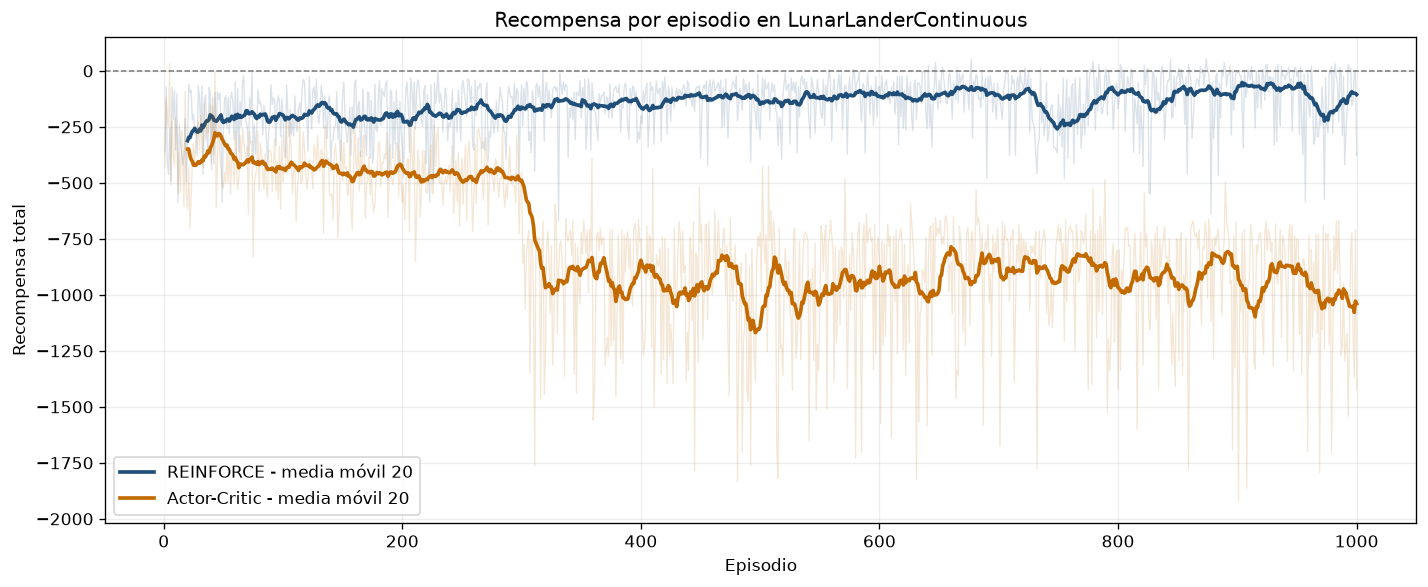

In [5]:
COLORS = {'REINFORCE': '#1f4e79', 'Actor-Critic': '#c26a00'}
RESULTS = {'REINFORCE': reinforce_results, 'Actor-Critic': actor_critic_results}
WINDOW = 20

figure = plt.figure(figsize=(12, 5))
for name, result in RESULTS.items():
    rewards = np.asarray(result['metrics']['episode_rewards'])
    episodes = np.arange(1, len(rewards) + 1)
    plt.plot(episodes, rewards, color=COLORS[name], alpha=0.16, linewidth=0.8)
    smooth = moving_average(rewards, WINDOW)
    plt.plot(episodes[WINDOW - 1:], smooth, color=COLORS[name], linewidth=2.2, label=f'{name} - media móvil 20')
plt.axhline(0, color='#777777', linewidth=0.9, linestyle='--')
plt.title('Recompensa por episodio en LunarLanderContinuous')
plt.xlabel('Episodio')
plt.ylabel('Recompensa total')
plt.legend()
plt.grid(alpha=0.22)
plt.tight_layout()
display_figure(figure)


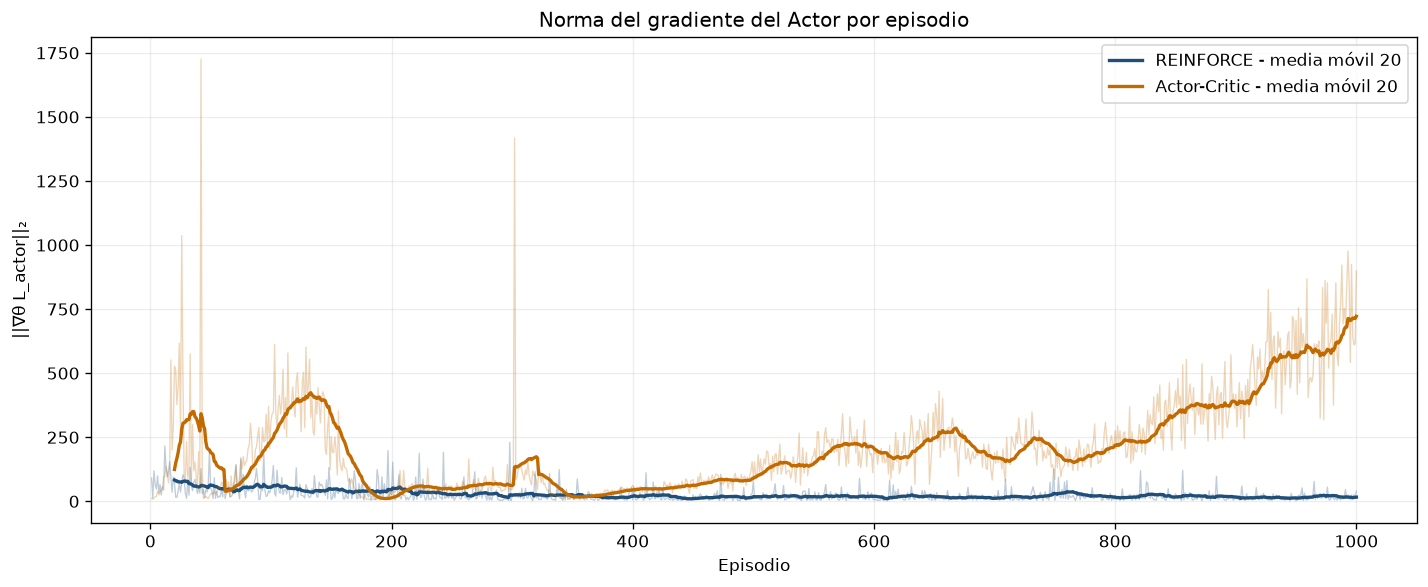

In [6]:
figure = plt.figure(figsize=(12, 5))
for name, result in RESULTS.items():
    norms = np.asarray(result['metrics']['actor_grad_norms'])
    plt.plot(np.arange(1, len(norms) + 1), norms, color=COLORS[name], alpha=0.28, linewidth=0.8)
    smooth = moving_average(norms, WINDOW)
    plt.plot(np.arange(WINDOW, len(norms) + 1), smooth, color=COLORS[name], linewidth=2.0, label=f'{name} - media móvil 20')
plt.title('Norma del gradiente del Actor por episodio')
plt.xlabel('Episodio')
plt.ylabel(r'||∇θ L_actor||₂')
plt.legend()
plt.grid(alpha=0.22)
plt.tight_layout()
display_figure(figure)


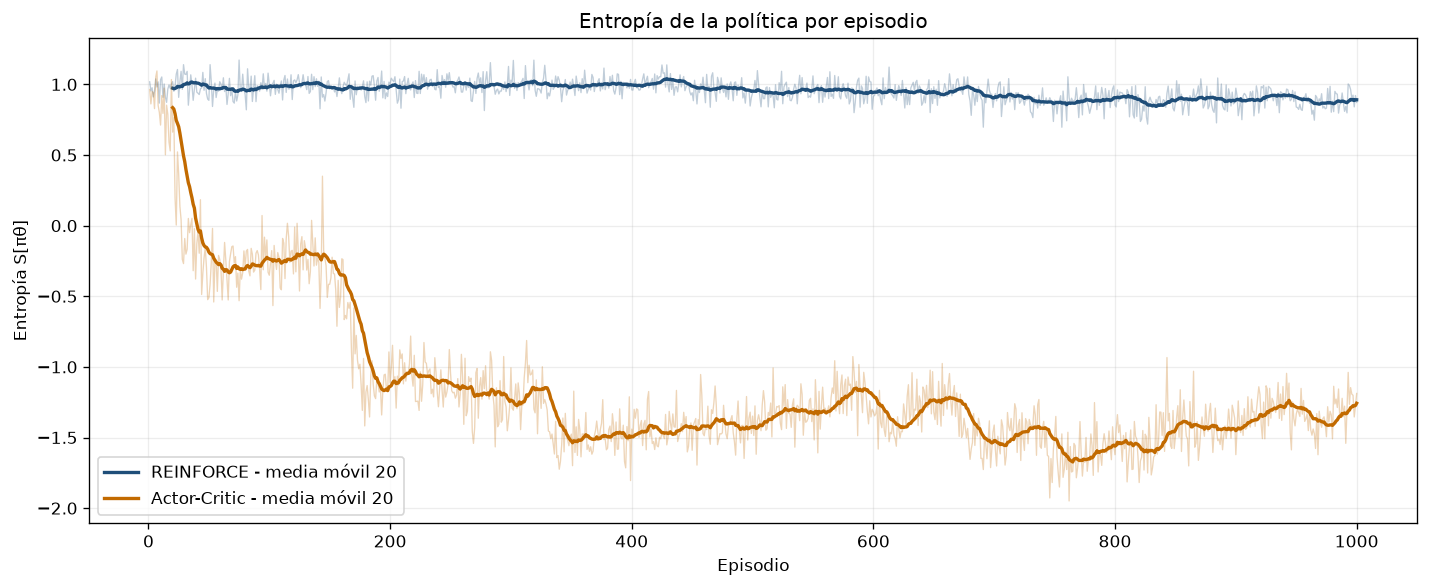

In [7]:
figure = plt.figure(figsize=(12, 5))
for name, result in RESULTS.items():
    entropies = np.asarray(result['metrics']['policy_entropies'])
    plt.plot(np.arange(1, len(entropies) + 1), entropies, color=COLORS[name], alpha=0.28, linewidth=0.8)
    smooth = moving_average(entropies, WINDOW)
    plt.plot(np.arange(WINDOW, len(entropies) + 1), smooth, color=COLORS[name], linewidth=2.0, label=f'{name} - media móvil 20')
plt.title('Entropía de la política por episodio')
plt.xlabel('Episodio')
plt.ylabel('Entropía S[πθ]')
plt.legend()
plt.grid(alpha=0.22)
plt.tight_layout()
display_figure(figure)


### 5.5 Visualización de una política aprendida con `env.render()`

Se ejecuta una trayectoria determinista usando la media `μθ(s)` de cada política y se capturan los frames RGB devueltos por `env.render()`.

REINFORCE: 158 frames, recompensa = -315.29
Actor-Critic: 77 frames, recompensa = -833.43


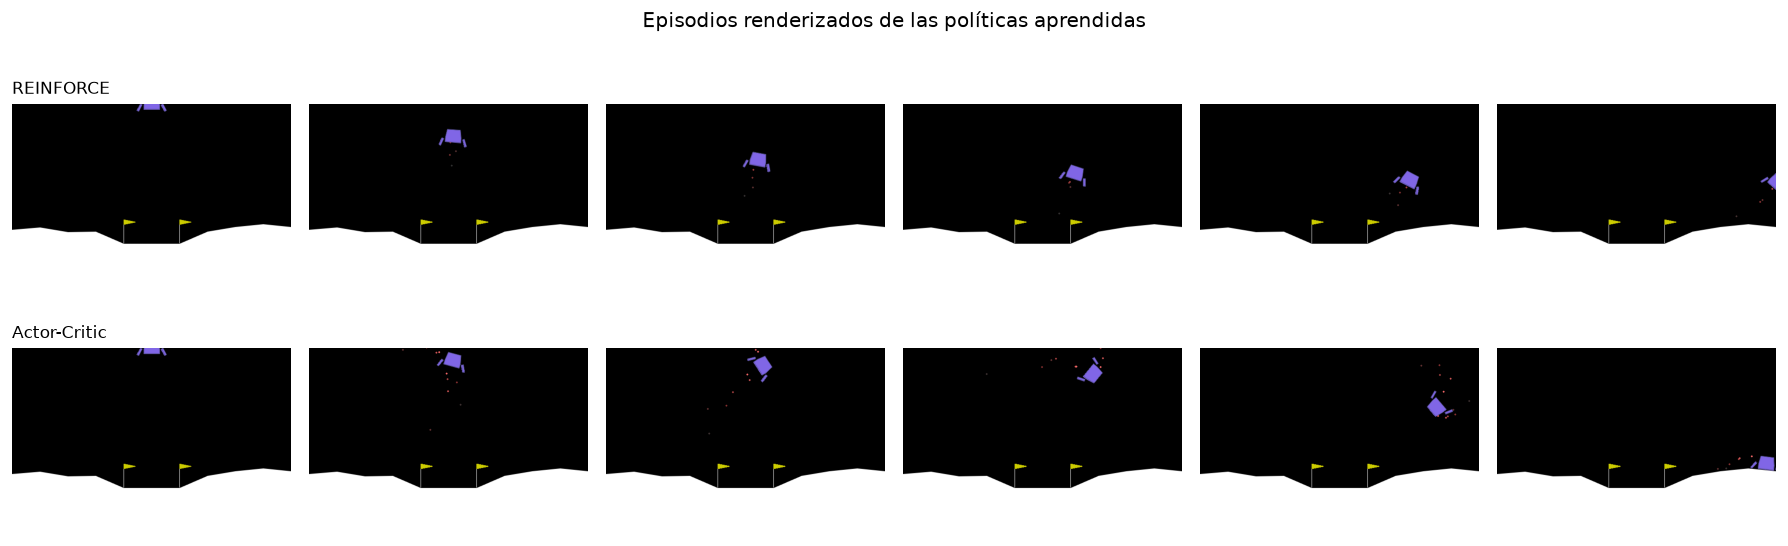

In [8]:
def rollout_for_render(policy, seed=SEED, max_steps=1000):
    env = make_env(render_mode='rgb_array')
    frames, rewards = [], []
    try:
        state = reset_env(env, seed=seed)
        done = False
        for _ in range(max_steps):
            frame = render_frame(env)
            if frame is not None:
                frames.append(np.asarray(frame))
            with torch.no_grad():
                action = policy.mean_action(state_tensor(state)).squeeze(0).cpu().numpy()
            next_state, reward, terminated, truncated, _ = step_env(env, action)
            rewards.append(reward)
            state = next_state
            done = terminated or truncated
            if done:
                final_frame = render_frame(env)
                if final_frame is not None:
                    frames.append(np.asarray(final_frame))
                break
    finally:
        env.close()
    return frames, float(np.sum(rewards))


rendered_episodes = {}
for name, result in RESULTS.items():
    frames, reward = rollout_for_render(result['policy'], seed=SEED + 10000)
    rendered_episodes[name] = {'frames': frames, 'reward': reward}
    print(f'{name}: {len(frames)} frames, recompensa = {reward:.2f}')

figure = plt.figure(figsize=(15, 5))
n_columns = 6
for row, (name, data) in enumerate(rendered_episodes.items()):
    frames = data['frames']
    if not frames:
        raise RuntimeError('env.render() no devolvió frames RGB para esta política.')
    indices = np.linspace(0, len(frames) - 1, n_columns, dtype=int)
    for column, frame_index in enumerate(indices):
        axis = plt.subplot(len(rendered_episodes), n_columns, row * n_columns + column + 1)
        axis.imshow(frames[frame_index])
        axis.axis('off')
        if column == 0:
            axis.set_title(name, loc='left', fontsize=10)
        axis.set_xlabel(f't={frame_index}', fontsize=8)
plt.suptitle('Episodios renderizados de las políticas aprendidas')
plt.tight_layout()
display_figure(figure)


# Tarea 2 - Análisis experimental y bibliográfico

El análisis usa la ejecución reproducible anterior: `SEED = 42`, `N_EPISODES = 1000`, `gamma = 0.99`, una semilla de reinicio `SEED + episodio` para ambos algoritmos y una evaluación determinista independiente de 10 episodios. Las conclusiones se refieren a esta corrida y no se presentan como una garantía estadística de todas las semillas. La entropía registrada es una estimación Monte Carlo de la entropía diferencial de la política transformada, `-log pi(a|s)`, por lo que puede ser negativa y no tiene que coincidir con la entropía de la Gaussiana sin transformar.

## 1. Contraste de las predicciones de la Tarea 1

1. **Política explícita para acciones continuas - Confirmada.** El entorno tiene acciones continuas y ambas implementaciones producen un vector acotado por `tanh`, sin discretizar la acción.

2. **Actor-Critic debía aprender más rápido y obtener mejor desempeño relativo - Refutada en esta corrida.** REINFORCE terminó con media móvil de 20 de `-105.66` y evaluación determinista `-298.95 ± 26.24`, mientras Actor-Critic terminó con `-1039.71` y `-1128.90 ± 396.54`. La señal TD no garantizó estabilidad: el Critic se actualiza paso a paso, comparte el cuerpo con el Actor y su error puede retroalimentar una política mala. Es una refutación de esta configuración y semilla, no una prueba de que Actor-Critic sea inferior en general.

3. **REINFORCE debía presentar más varianza y el Critic reducir el ruido - Refutada en esta configuración.** El gradiente de Actor-Critic fue mayor: mediana `160.05`, q95 `602.08` y máximo `1726.34`, frente a `15.78`, `89.67` y `230.10` de REINFORCE. El bootstrap TD y el cuerpo compartido introdujeron inestabilidad cuando el Critic aún era impreciso; la línea base separada de REINFORCE funcionó mejor aquí. La expectativa teórica requiere ajustes de tasa de aprendizaje, normalización de ventajas y más semillas antes de generalizar.

4. **Actor-Critic por sí solo produciría acciones suficientemente suaves - Inconclusa.** Esta práctica no incluye una penalización `||a_t-a_{t-1}||^2`, una restricción de slew-rate ni el registro de variación de acciones. Mejor recompensa no demuestra suavidad; en hardware se requiere medirla y limitarla explícitamente.

5. **La entropía decrecería gradualmente y de forma casi monótona - Refutada por la corrida.** La política tiene `log_std` aprendible y no se incluyó bonus entrópico; el gradiente puede aumentar la exploración cuando la señal de recompensa es ruidosa. Por ello la entropía puede oscilar o incluso subir aunque la media móvil de recompensa mejore.

## 2. Norma del gradiente y estabilidad

La métrica por episodio es la norma L2 del gradiente del término del Actor antes de aplicar `clip_grad_norm_(..., max_norm=5)`. Por eso registra la señal que habría producido el paso, no simplemente una norma ya recortada. El resumen usa una regla robusta para llamar anómalo a un valor mayor que `mediana + 6 * MAD`, y reporta también el cuantil 95 y los cinco episodios más extremos.

En REINFORCE, la norma tuvo mediana `15.7829`, q95 `89.6733` y máximo `230.1021`. Los valores altos se concentraron sobre todo al inicio; varias coincidencias con caídas de recompensa aparecen en los episodios `3`, `6`, `12`, `19`, `33`, `42` y `49`. Aun con esas oscilaciones, la media móvil pasó de `-311.72` en los primeros 20 episodios a `-105.66` en los últimos 20 y alcanzó `-51.68` cerca del episodio 904. Esto sugiere ruido con progreso neto, no una explosión sostenida.

En Actor-Critic, la norma fue mucho mayor: mediana `160.0545`, q95 `602.0758` y máximo `1726.3405`. El máximo y varios valores anómalos aparecen cuando la recompensa ya estaba deteriorándose; hubo coincidencias explícitas en los episodios `959`, `993` y `1000`, y la media móvil cayó desde un pico de `-276.28` en el episodio 43 hasta `-1039.71` al final. En esta implementación la señal TD no redujo la varianza: el bootstrap sesgado, las actualizaciones por paso, el cuerpo compartido y la misma tasa de aprendizaje explican una posible amplificación del error. El recorte a 5 evita explosiones numéricas en el update, pero no arregla una dirección mal estimada.

Esta observación motiva PPO: REINFORCE y Actor-Critic pueden proponer un cambio grande aun cuando una muestra tenga una ventaja extrema. PPO reutiliza datos con un cociente de probabilidades y recorta el surrogate a `[1-epsilon, 1+epsilon]`; así desacopla parcialmente el tamaño del paso de un único retorno y controla cuánto se aleja la política nueva de la antigua. No reemplaza los límites de seguridad ni garantiza suavidad temporal.

## 3. Evolución de la entropía

La gráfica y el resumen numérico permiten localizar el intervalo de 20 episodios con la pendiente más negativa. REINFORCE pasó de entropía media `0.9727` a `0.8912` y su descenso más rápido ocurrió cerca del episodio 904; Actor-Critic pasó de `0.8352` a `-1.2574` y cayó más rápido cerca del episodio 38. Por tanto, la predicción de una disminución gradual y monótona queda refutada: Actor-Critic colapsó su exploración temprano, mientras REINFORCE disminuyó lentamente y con oscilaciones. La desviación estándar global se aprende junto con la media y no hay un bonus que controle explícitamente la tasa de esa reducción.

Agregar un término de entropía a la pérdida del Actor, por ejemplo `L_actor - beta * S[pi]` al minimizar, premia distribuciones con mayor incertidumbre. Al inicio evitaría que `sigma` colapse y mantendría exploración; durante el entrenamiento haría menos probable una política prematuramente determinista y puede suavizar cambios entre actualizaciones. El costo es que un `beta` fijo puede conservar demasiada exploración, degradar el aterrizaje final o producir acciones ruidosas. En PPO normalmente se combina con clipping y un coeficiente que puede decaer, no se usa como sustituto del control de seguridad.

## 4. Investigación bibliográfica: exoesqueleto y PPO

**Referencia:** Shuzhen Luo, Menghan Jiang, Sainan Zhang, Junxi Zhu, Shuangyue Yu, Israel Dominguez Silva, Tian Wang, Elliott Rouse, Bolei Zhou, Hyunwoo Yuk, Xianlian Zhou y Hao Su, *Experiment-free exoskeleton assistance via learning in simulation*, **Nature**, vol. 630, pp. 353-359, 2024. DOI: [10.1038/s41586-024-07382-4](https://doi.org/10.1038/s41586-024-07382-4). Se consultaron el artículo y sus [materiales suplementarios](https://haosu-robotics.github.io/PDFs/Nature%20supplementary%20materials.pdf).

El problema es diseñar asistencia para locomoción sin depender de muchas horas de pruebas humanas ni de reglas hechas a mano para cada actividad. Luo et al. construyen un entorno de simulación musculoesquelético y del exoesqueleto consciente de la dinámica: un modelo humano de cuerpo completo, 208 músculos, contacto humano-robot y redes para imitación de movimiento, coordinación muscular y control del exoesqueleto. El controlador aprende perfiles continuos de torque y transiciones entre caminar, correr y subir escaleras; después se transfiere a un exoesqueleto de cadera físico.

El algoritmo de gradiente de política es **PPO**, implementado junto con una función de valor Actor-Critic. El Actor propone la política y el Critic estima el valor; PPO optimiza el surrogate con razón de verosimilitudes y clipping, con `epsilon = 0.2`, para evitar que una actualización cambie demasiado la política. Es una elección razonable porque el control es continuo, RL es costoso en simulación y el artículo busca eficiencia y estabilidad: reporta unos 20 millones de muestras generadas en línea y alrededor de 8 horas de entrenamiento en GPU. La aleatorización de parámetros del robot, latencia, fuerza muscular y otras propiedades intenta cerrar la brecha sim-to-real.

El controlador desplegado en un exoesqueleto de cadera de 3.2 kg usa un IMU de nueve ejes por muslo y asiste varias modalidades sin entrenamiento humano adicional. En ocho participantes por actividad, el artículo reporta reducciones de la tasa metabólica de 24.3% al caminar, 13.1% al correr y 15.4% al subir escaleras frente a la condición sin exoesqueleto. Frente a nuestros experimentos, PPO resuelve la fragilidad de pasos grandes mediante clipping y reduce el problema de alta varianza de un retorno completo usando un Critic; la simulación dinámica y la aleatorización también atacan la escasez de datos reales. Persisten la dependencia de una función de recompensa bien diseñada, la validez del modelo humano, la seguridad ante sujetos distintos, la adaptación clínica y la suavidad bajo perturbaciones no representadas. Además, al momento de esta entrega la página de Nature muestra una nota editorial del 27 de julio de 2026 que advierte preocupaciones sobre disponibilidad de datos y código; por eso los resultados son una referencia prometedora, pero deben reproducirse y auditarse antes de extrapolarlos a hardware médico.

## 5. Recomendación para el equipo directivo

Como punto de partida para el sistema real recomendamos **Actor-Critic**, pero únicamente después de estabilizarlo; REINFORCE debe permanecer como baseline de validación. La evidencia de esta corrida es incómoda y útil: REINFORCE terminó en `-105.66` frente a `-1039.71` de Actor-Critic, con normas de gradiente mucho menores, aunque su retorno completo tenga una desventaja teórica de varianza. El Actor-Critic actual sufrió picos y una caída tardía, de modo que no se debe justificar su uso solo por la expectativa teórica de menor varianza. Su ventaja práctica es que escala mejor a señales frecuentes y a funciones de valor, pero exige ajustar learning rate, normalizar ventajas y validar el Critic. Antes de hardware, debe incorporar límites de torque, tasa de cambio, detección de fallas, saturación explícita y una recompensa que penalice variaciones de acción.

Sí recomendamos escalar a **PPO antes del despliegue**, pero en simulación y con un protocolo de seguridad, no saltar directamente a hardware. Los picos de norma observados ilustran el riesgo de pasos grandes; PPO agrega clipping de la razón de política, un Critic y normalmente un bonus de entropía, mecanismos alineados con estabilidad y exploración controlada. El trabajo de Luo et al. muestra por qué esta combinación es atractiva para control de exoesqueleto y cómo la aleatorización puede ayudar al sim-to-real, pero no elimina la necesidad de validar suavidad temporal: se deben medir `||a_t-a_{t-1}||`, torque, jerk, latencia y respuestas a perturbaciones, y usar domain randomization, evaluación fuera de distribución, shadow mode y límites independientes del aprendizaje. La puerta a hardware debe abrirse solo después de esas pruebas, no por alcanzar una recompensa alta en LunarLander.

## Referencias consultadas

1. Luo, S. et al. (2024). *Experiment-free exoskeleton assistance via learning in simulation*. Nature, 630, 353-359. [DOI](https://doi.org/10.1038/s41586-024-07382-4).
2. Luo, S. et al. (2024). Materiales suplementarios, sección Supplementary Text 3: *Control policy network training using proximal policy optimization to improve efficiency*. [PDF](https://haosu-robotics.github.io/PDFs/Nature%20supplementary%20materials.pdf).
3. Repositorio de pseudocódigo enlazado por los autores: [IntelligentRobotLearning/pseudocode_learning_in_simulation](https://github.com/IntelligentRobotLearning/pseudocode_learning_in_simulation).